In [1]:
# Librerias necesarias

import pandas as pd
import numpy as np
import io
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import folium
from folium.plugins import HeatMap, MarkerCluster
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, silhouette_score, davies_bouldin_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from branca.element import Template, MacroElement
from sklearn.cluster import KMeans, DBSCAN
from imblearn.over_sampling import SMOTE, ADASYN
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler

#Gestión y Transformación de Datos

En el primer bloque, se realiza un análisis de la estructura de los datos, identificando los tipos de variables contenidas en el dataset, junto con una revisión de la existencia o no de datos nulos. Las variables *X* e *Y* corresponden a las coordenadas del accidente, "*Ubicación*" nos indica en que calles ocurrió este, las variables asociadas a la gravedad (*Fallecidos*, *Graves*, *Menos grave*, *Leve*) dan cuenta de la categorización de la gravedad del accidente, siendo 0 o 1 según la clasificación que corresponda, y la variable "*Accidente*" cuantifica la cantidad de accidentes asociados a cada "*Ubicación*". Por último, se crearon 2 variables auxiliares: "*Comuna*" la cual extrae desde "*Ubicación*" la comuna de ocurrencia del accidente, y "*Es_grave*" para agrupar *Fallecidos*/*Graves* dentro de esta variable, tomando un valor de 1, y *Menos grave*/*Leve* que toman el valor 0.

In [2]:
# Revisión Inicial de los datos

# Carga del dataset
try:
    df = pd.read_csv('AtropellosGS2015.csv')
    print("Archivo 'AtropellosGS2015.csv' cargado localmente.")
except Exception:
    print("Por favor, sube el archivo 'AtropellosGS2015.csv'")
    uploaded = files.upload()
    df = pd.read_csv(io.BytesIO(uploaded[list(uploaded.keys())[0]]))

print("--- 1. ANÁLISIS DE ESTRUCTURA ---")
print(f"Total de registros: {df.shape[0]}")
print(f"Total de variables: {df.shape[1]}")
display(df.info())

# Revisión de Valores Nulos
print("\n--- 2. DETECCIÓN DE VALORES NULOS ---")
display(df.isnull().sum())

# Extraer Comuna
# Comuna se encuentra después del nombre de las calles, a continuación de una ","
df['Comuna'] = df['Ubicacion'].apply(lambda x: x.split(',')[-1].strip() if ',' in x else 'DESCONOCIDA')

# Crear Variable Objetivo Binaria "Es_Grave"
# Se define como Es_grave si hubo fallecidos o heridos graves
df['Es_Grave'] = ((df['Fallecidos'] > 0) | (df['Graves'] > 0)).astype(int)

sns.set_theme(style="whitegrid")
print(f"\nDataset cargado. Registros: {df.shape[0]}")
print(f"Comunas identificadas: {df['Comuna'].nunique()}")
df.head()

Por favor, sube el archivo 'AtropellosGS2015.csv'


Saving AtropellosGS2015.csv to AtropellosGS2015.csv
--- 1. ANÁLISIS DE ESTRUCTURA ---
Total de registros: 1841
Total de variables: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1841 entries, 0 to 1840
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   X           1841 non-null   float64
 1   Y           1841 non-null   float64
 2   Ubicacion   1841 non-null   object 
 3   Fallecidos  1841 non-null   int64  
 4   Graves      1841 non-null   int64  
 5   MenosGrave  1841 non-null   int64  
 6   Leve        1841 non-null   int64  
 7   Accidentes  1841 non-null   int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 115.2+ KB


None


--- 2. DETECCIÓN DE VALORES NULOS ---


,0
X,0
Y,0
Ubicacion,0
Fallecidos,0
Graves,0
MenosGrave,0
Leve,0
Accidentes,0



Dataset cargado. Registros: 1841
Comunas identificadas: 33


,X,Y,Ubicacion,Fallecidos,Graves,MenosGrave,Leve,Accidentes,Comuna,Es_Grave
0,-70.798508,-33.364435,"CAMINO RENCA LAMPA & CAMINO AGUAS CLARAS, PUDA...",0,1,0,0,1,PUDAHUEL,1
1,-70.797142,-33.354941,"CAMINO LO ECHEVERS & CAMINO PRIVADO, QUILICURA",0,1,0,0,1,QUILICURA,1
2,-70.797944,-33.511716,"EL CONQUISTADOR & SENADORA MARIA DE LA CRUZ, M...",0,1,0,1,1,MAIPU,1
3,-70.797199,-33.513151,"EL CONQUISTADOR & PINTOR HORACIO GARCIA, MAIPU",0,1,0,0,1,MAIPU,1
4,-70.797021,-33.518601,"1370 EL CONQUISTADOR, MAIPU",0,1,0,0,1,MAIPU,1


#Visualización de Frecuencias según gravedad

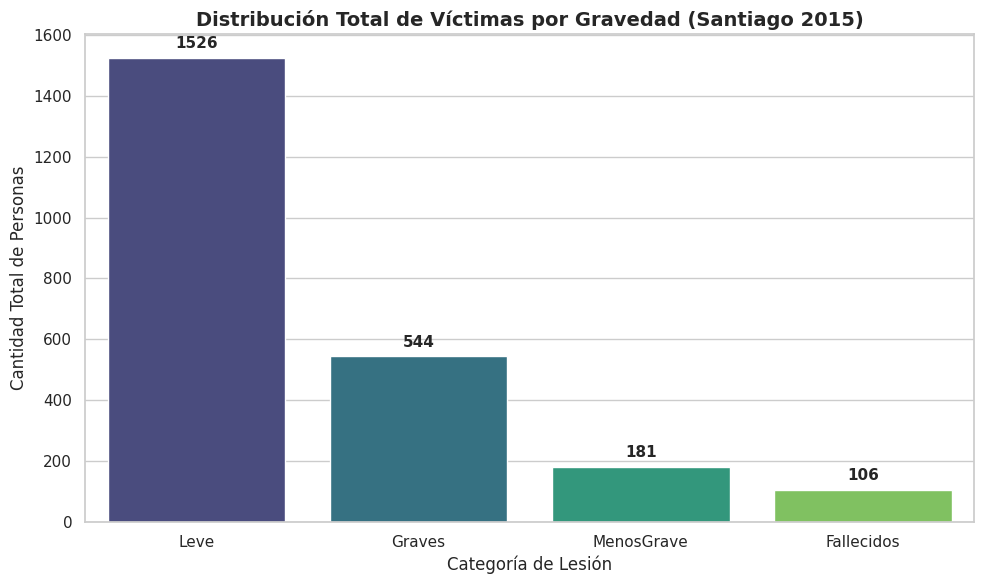

In [3]:
# Definición de las columnas de interés
columnas_lesiones = ['Fallecidos', 'Graves', 'MenosGrave', 'Leve']

# Suma del total de víctimas por categoría para ver el impacto global
totales_danos = df[columnas_lesiones].sum().sort_values(ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(
    x=totales_danos.index,
    y=totales_danos.values,
    hue=totales_danos.index,
    palette='viridis',
    legend=False
)

plt.title('Distribución Total de Víctimas por Gravedad (Santiago 2015)', fontsize=14, fontweight='bold')
plt.ylabel('Cantidad Total de Personas')
plt.xlabel('Categoría de Lesión')

# Añadir etiquetas de valor sobre las barras
for i, v in enumerate(totales_danos.values):
    plt.text(i, v + (max(totales_danos.values) * 0.02), str(int(v)),
             ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

#Frecuencia de Atropellos por Comuna

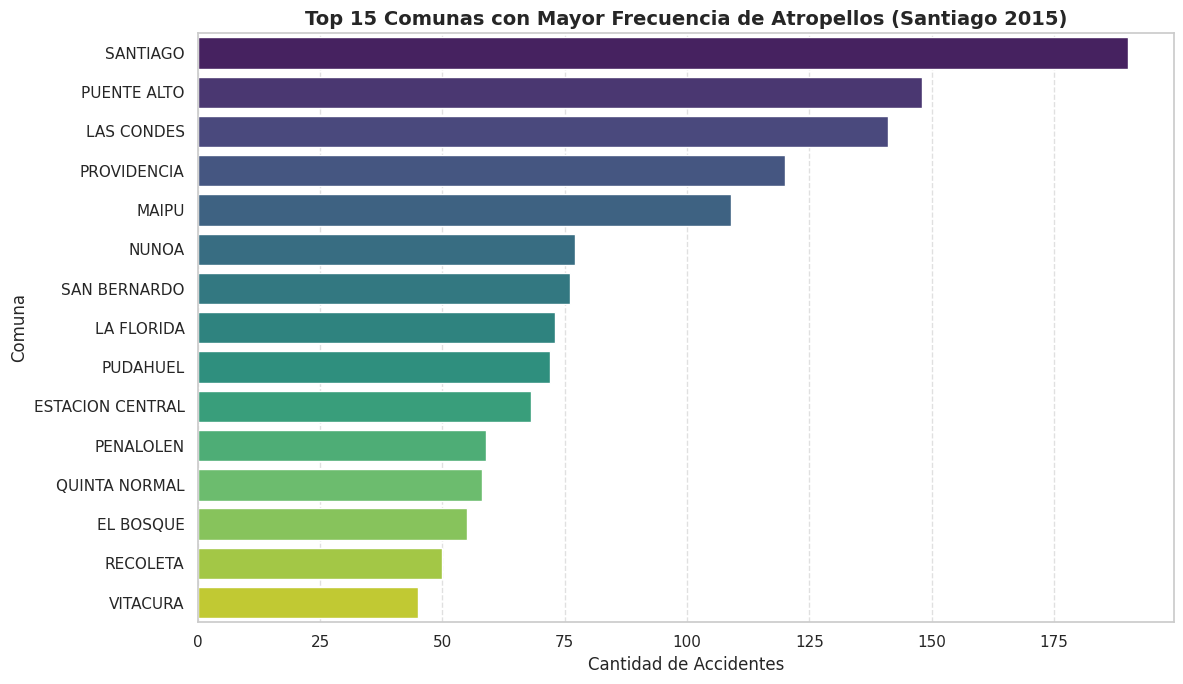

In [4]:
plt.figure(figsize=(12, 7))

# Obtenemos las 15 comunas con más registros
top_comunas = df['Comuna'].value_counts().head(15)

sns.barplot(
    x=top_comunas.values,
    y=top_comunas.index,
    hue=top_comunas.index,
    palette='viridis',
    legend=False
)

plt.title('Top 15 Comunas con Mayor Frecuencia de Atropellos (Santiago 2015)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Accidentes')
plt.ylabel('Comuna')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#Distribución Geoespacial de Accidentes (X vs Y)

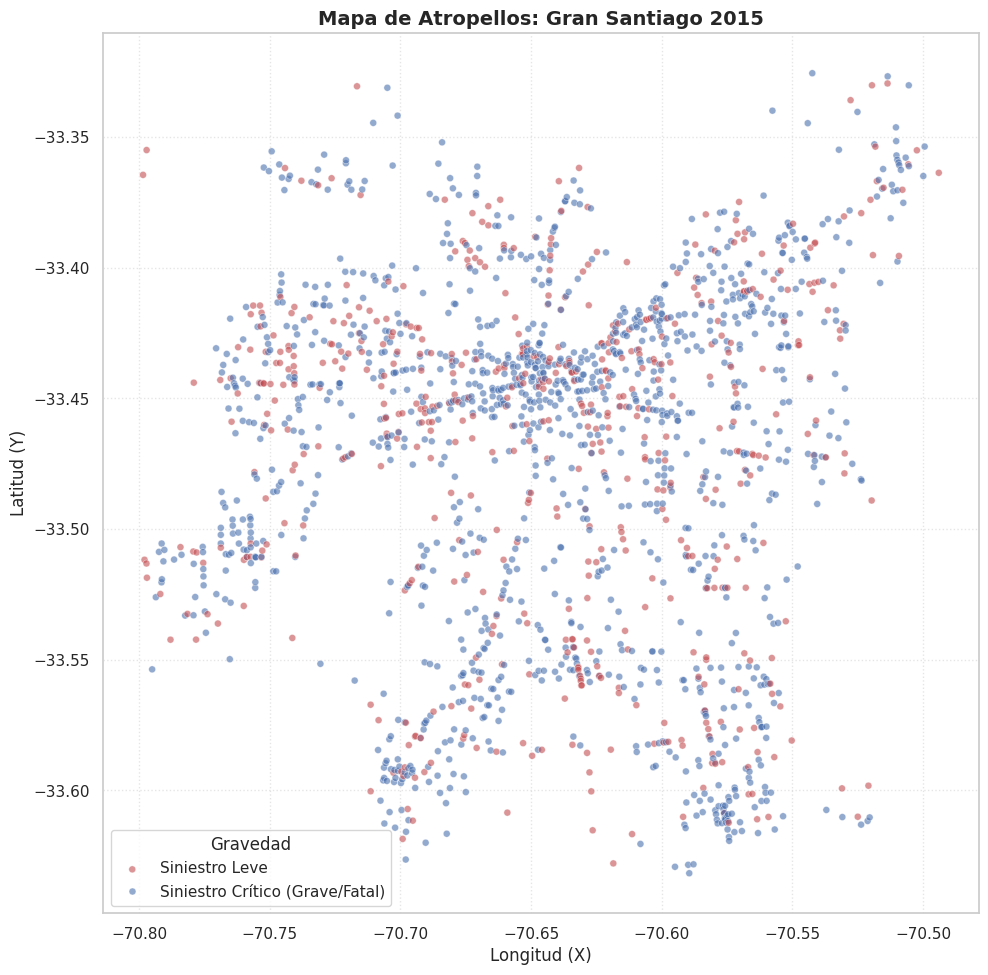

In [5]:
plt.figure(figsize=(10, 10))

# Graficamos diferenciando por 'Es_Grave' (0: Leve, 1: Grave/Fatal)
sns.scatterplot(
    data=df,
    x='X',
    y='Y',
    hue='Es_Grave',
    palette={0: '#4c72b0', 1: '#c44e52'},
    alpha=0.6,
    s=25
)

plt.title('Mapa de Atropellos: Gran Santiago 2015', fontsize=14, fontweight='bold')
plt.xlabel('Longitud (X)')
plt.ylabel('Latitud (Y)')
plt.legend(title='Gravedad', labels=['Siniestro Leve', 'Siniestro Crítico (Grave/Fatal)'])

# Relación de aspecto para no deformar el mapa
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

#Preprocesamiento y Escalado de Variables

Dado que los modelos de aprendizaje automático son sensibles a las magnitudes de las variables, aplicamos StandardScaler para normalizar los datos (media 0 y varianza 1). Esto es crítico para algoritmos basados en distancias (como K-Means o DBSCAN) y para acelerar la convergencia de la Red Neuronal. Asimismo, se divide el conjunto de datos en entrenamiento (Train) y prueba (Test) para validar la capacidad de generalización de los modelos.


--- CORRELACIÓN: UBICACIÓN VS CRITICIDAD ---


,X,Y,Siniestro_Critico
X,1.000000,0.007775,-0.015719
Y,0.007775,1.000000,0.021057
Siniestro_Critico,-0.015719,0.021057,1.000000


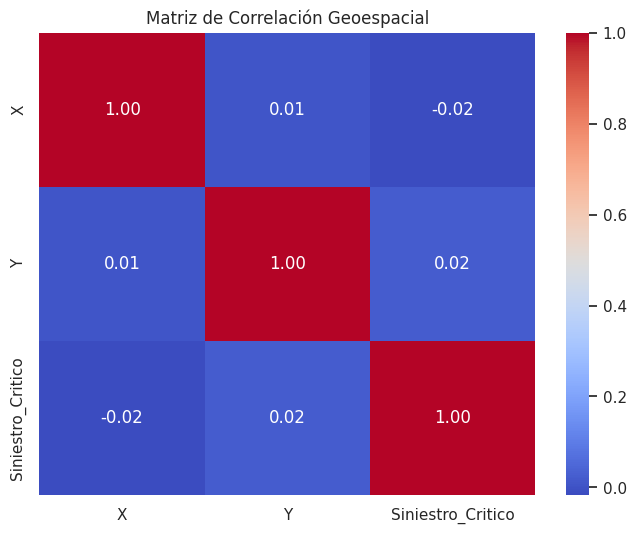

In [6]:
# Crear Target: 1 si hubo Fallecidos o Graves, 0 si no.
df['Siniestro_Critico'] = ((df['Fallecidos'] > 0) | (df['Graves'] > 0)).astype(int)

# Análisis de Correlación
# ¿Afecta la ubicación (X, Y) a la probabilidad de un siniestro crítico?
print("\n--- CORRELACIÓN: UBICACIÓN VS CRITICIDAD ---")
correlacion = df[['X', 'Y', 'Siniestro_Critico']].corr()
display(correlacion)

# Visualización de la Correlación
plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación Geoespacial')
plt.show()

La matriz de correlación entre ubicación y criticidad muestra coeficientes cercanos a cero (r≈0.02), lo que demuestra que la gravedad de los atropellos en el Gran Santiago no sigue una progresión lineal geográfica. Este hallazgo nos permite anticipar el posible descarte de modelos predictivos lineales.

In [7]:
# Normalización y Balanceo de Datos (SMOTE)

# Selección de Variables Predictoras (Features) y Objetivo (Target)
X_geo = df[['X', 'Y']]
y_geo = df['Es_Grave'] # Usamos el nombre definido en tu Bloque 1

# Partición de datos (Train/Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_geo, y_geo, test_size=0.2, random_state=42, stratify=y_geo
)

# Normalización (Estandarización)
# Normalizar ANTES de aplicar SMOTE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Balanceo de Clases con SMOTE, solo balanceamos el set de ENTRENAMIENTO
print(f"Distribución original en Entrenamiento: {Counter(y_train)}")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Distribución balanceada en Entrenamiento: {Counter(y_train_res)}")

# Reporte
print("\n--- RESULTADO DE LA PREPARACIÓN FINAL ---")
print(f"Media de X normalizada: {X_train_res[:, 0].mean():.4f}")
print(f"Desviación estándar de X: {X_train_res[:, 0].std():.4f}")

# Convertir a DataFrame para visualización posterior
X_train_final = pd.DataFrame(X_train_res, columns=['X_Normalizada', 'Y_Normalizada'])
display(X_train_final.head())

Distribución original en Entrenamiento: Counter({0: 1015, 1: 457})
Distribución balanceada en Entrenamiento: Counter({0: 1015, 1: 1015})

--- RESULTADO DE LA PREPARACIÓN FINAL ---
Media de X normalizada: -0.0088
Desviación estándar de X: 1.0070


,X_Normalizada,Y_Normalizada
0,1.119276,0.022463
1,-0.152112,0.593558
2,0.652797,-1.600979
3,1.013436,-2.044685
4,-1.578817,0.330625


#Elaboración de Modelos: Partición y Balanceo de Clases

El dataset se dividió en entrenamiento (80%) y prueba (20%) con estratificación para mantener la proporción de la clase. El conjunto de prueba (X_test, y_test) se reservó para la evaluación final independiente de los modelos, garantizando una estimación imparcial de su capacidad de generalización.
Debido al desequilibrio de clases en la variable 'Es_Grave', se implementan tres técnicas de balanceo (SMOTE (sobremuestreo), ADASYN (sobremuestreo adaptativo) y RandomUnderSampler (submuestreo)) sobre el *conjunto de entrenamiento*. El objetivo es comparar su efecto en el rendimiento del modelo y evitar sesgos hacia la clase mayoritaria.

Para abordar el desequilibrio de clases en la variable
Es_Grave y asegurar que nuestros modelos no ignoren la clase minoritaria
(siniestros críticos), se aplicarán tres técnicas de balanceo. Estas técnicas modificarán el conjunto de entrenamiento para equilibrar la
proporción de las clases, permitiendo una mejor capacidad de detección por parte de los modelos.

In [8]:
# Las variables X_train_scaled, y_train, X_test_scaled, y_test ya están disponibles en el entorno del kernel.
# Se usará X_train_scaled y y_train como base para los nuevos balanceos.
print("--- APLICANDO TÉCNICAS DE BALANCEO DE CLASES ---")
# 1. Random Under-Sampler (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)
print(f"Distribución con RandomUnderSampler: {Counter(y_train_rus)}")
# 2. ADASYN
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
print(f"Distribución con ADASYN: {Counter(y_train_adasyn)}")
# SMOTE ya fue aplicado en una sección anterior, usando X_train_res y y_train_res
# Se mantiene la variable X_train_res y y_train_res con los datos balanceados por SMOTE
print(f"Distribución con SMOTE (pre-existente): {Counter(y_train_res)}")

--- APLICANDO TÉCNICAS DE BALANCEO DE CLASES ---
Distribución con RandomUnderSampler: Counter({0: 457, 1: 457})
Distribución con ADASYN: Counter({0: 1015, 1: 945})
Distribución con SMOTE (pre-existente): Counter({0: 1015, 1: 1015})


In [9]:
# --- Funciones para entrenar y evaluar modelos (para evitar duplicación de código) --
def evaluate_supervised_models(X_train, y_train, X_test, y_test, technique_name):
    modelos_ml = {
        "Regresión Logística": LogisticRegression(random_state=42, solver='liblinear'),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "XGBoost": XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)
    }

    results = []
    print(f"\n--- Entrenando Modelos ML con {technique_name} ---")
    for nombre, modelo in modelos_ml.items():
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        y_prob = modelo.predict_proba(X_test)[:, 1]
        results.append({
            "Modelo": nombre,
            "Balanceo": technique_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "AUC-ROC": roc_auc_score(y_test, y_prob)
        })
        print(f"{nombre} finalizado con {technique_name}.")
    return results
def crear_modelo_dl(capas):
    model = Sequential([Input(shape=(X_train_scaled.shape[1],))])
    for neuronas in capas:
        model.add(Dense(neuronas, activation='relu'))
        model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model
def evaluate_dl_models(X_train, y_train, X_test, y_test, technique_name, arquitecturas_list):
    results = []
    histories = {}
    print(f"\n--- Entrenando Modelos DL con {technique_name} ---")
    for capas, nombre in arquitecturas_list:
        model = crear_modelo_dl(capas)
        history = model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
        histories[f"{nombre} ({technique_name})"] = history.history
        y_prob = model.predict(X_test, verbose=0).ravel()
        y_pred = (y_prob > 0.5).astype(int)
        results.append({
            "Modelo": nombre,
            "Balanceo": technique_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "AUC-ROC": roc_auc_score(y_test, y_prob)
        })
        print(f"{nombre} finalizado con {technique_name}.")
    return results, histories

Una vez preparados los conjuntos de datos balanceados, se procede al entrenamiento y evaluación de los modelos de Machine Learning
(Regresión Logística, Random Forest, XGBoost) y Deep Learning (arquitecturas Simple, Profundo y Ancho). Cada modelo se entrenará con
los datos preprocesados por cada técnica de balanceo, y se evaluará su rendimiento utilizando métricas clave como Accuracy, Recall, F1
Score y AUC-ROC para identificar las combinaciones más prometedoras.

In [12]:
import pandas as pd
import warnings
from IPython.display import display

warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')

# --- Preparación de contenedores y configuraciones ---
all_ml_results = []
all_dl_results = []
dl_histories = {}

# Definición de arquitecturas de Redes Neuronales (DL)
arquitecturas = [
    ([16, 8], "DL Simple (2 capas)"),
    ([64, 32, 16, 8], "DL Profundo (4 capas)"),
    ([128, 128], "DL Ancho (Alta Capacidad)")
]

# 1. Evaluación con SMOTE
print("--- Iniciando entrenamiento con SMOTE ---")
all_ml_results.extend(evaluate_supervised_models(X_train_res, y_train_res, X_test_scaled, y_test, "SMOTE"))
dl_res_smote, dl_hist_smote = evaluate_dl_models(X_train_res, y_train_res, X_test_scaled, y_test, "SMOTE", arquitecturas)
all_dl_results.extend(dl_res_smote)
dl_histories.update(dl_hist_smote)

# 2. Evaluación con Random Under-Sampler (RUS)
print("--- Iniciando entrenamiento con RandomUnderSampler ---")
all_ml_results.extend(evaluate_supervised_models(X_train_rus, y_train_rus, X_test_scaled, y_test, "RandomUnderSampler"))
dl_res_rus, dl_hist_rus = evaluate_dl_models(X_train_rus, y_train_rus, X_test_scaled, y_test, "RandomUnderSampler", arquitecturas)
all_dl_results.extend(dl_res_rus)
dl_histories.update(dl_hist_rus)

# 3. Evaluación con ADASYN
print("--- Iniciando entrenamiento con ADASYN ---")
all_ml_results.extend(evaluate_supervised_models(X_train_adasyn, y_train_adasyn, X_test_scaled, y_test, "ADASYN"))
dl_res_adasyn, dl_hist_adasyn = evaluate_dl_models(X_train_adasyn, y_train_adasyn, X_test_scaled, y_test, "ADASYN", arquitecturas)
all_dl_results.extend(dl_res_adasyn)
dl_histories.update(dl_hist_adasyn)

# Crear DataFrames comparativos
df_ml_comparativa = pd.DataFrame(all_ml_results)
df_dl_comparativa = pd.DataFrame(all_dl_results)

# Combinar aprendizaje clásico (ML) y profundo (DL)
df_all_balanceo_comparativa = pd.concat([df_ml_comparativa, df_dl_comparativa], ignore_index=True)

print("\n" + "="*50)
print("--- COMPARATIVA FINAL DE MODELOS Y TÉCNICAS DE BALANCEO ---")
print("="*50)

# Mostrar resultados ordenados por Recall y F1-Score
display(df_all_balanceo_comparativa.sort_values(by=['Recall', 'F1-Score'], ascending=False))

--- Iniciando entrenamiento con SMOTE ---

--- Entrenando Modelos ML con SMOTE ---
Regresión Logística finalizado con SMOTE.
Random Forest finalizado con SMOTE.
XGBoost finalizado con SMOTE.

--- Entrenando Modelos DL con SMOTE ---
DL Simple (2 capas) finalizado con SMOTE.
DL Profundo (4 capas) finalizado con SMOTE.
DL Ancho (Alta Capacidad) finalizado con SMOTE.
--- Iniciando entrenamiento con RandomUnderSampler ---

--- Entrenando Modelos ML con RandomUnderSampler ---
Regresión Logística finalizado con RandomUnderSampler.
Random Forest finalizado con RandomUnderSampler.
XGBoost finalizado con RandomUnderSampler.

--- Entrenando Modelos DL con RandomUnderSampler ---
DL Simple (2 capas) finalizado con RandomUnderSampler.
DL Profundo (4 capas) finalizado con RandomUnderSampler.
DL Ancho (Alta Capacidad) finalizado con RandomUnderSampler.
--- Iniciando entrenamiento con ADASYN ---

--- Entrenando Modelos ML con ADASYN ---
Regresión Logística finalizado con ADASYN.
Random Forest finalizad

,Modelo,Balanceo,Accuracy,Recall,F1-Score,AUC-ROC
3,Regresión Logística,RandomUnderSampler,0.493225,0.614035,0.428135,0.557895
0,Regresión Logística,SMOTE,0.487805,0.578947,0.411215,0.524665
5,XGBoost,RandomUnderSampler,0.523035,0.570175,0.424837,0.569883
12,DL Simple (2 capas),RandomUnderSampler,0.482385,0.552632,0.397476,0.522291
4,Random Forest,RandomUnderSampler,0.514905,0.526316,0.401338,0.530134
8,XGBoost,ADASYN,0.528455,0.438596,0.364964,0.511283
11,DL Ancho (Alta Capacidad),SMOTE,0.514905,0.429825,0.353791,0.528001
10,DL Profundo (4 capas),SMOTE,0.569106,0.421053,0.376471,0.533368
9,DL Simple (2 capas),SMOTE,0.566396,0.412281,0.370079,0.516959
17,DL Ancho (Alta Capacidad),ADASYN,0.623306,0.403509,0.398268,0.535913


Esta tabla muestra las métricas de rendimiento (Accuracy, Recall, F1-Score, AUC-ROC) para los modelos de Machine Learning (Regresión
Logística, Random Forest, XGBoost) y Deep Learning (DL Simple, DL Profundo, DL Ancho), evaluados con diferentes técnicas de balanceo
de clases: SMOTE, RandomUnderSampler y ADASYN. Los resultados están ordenados por 'Recall' y 'F1-Score' para priorizar la capacidad
de detección de siniestros críticos

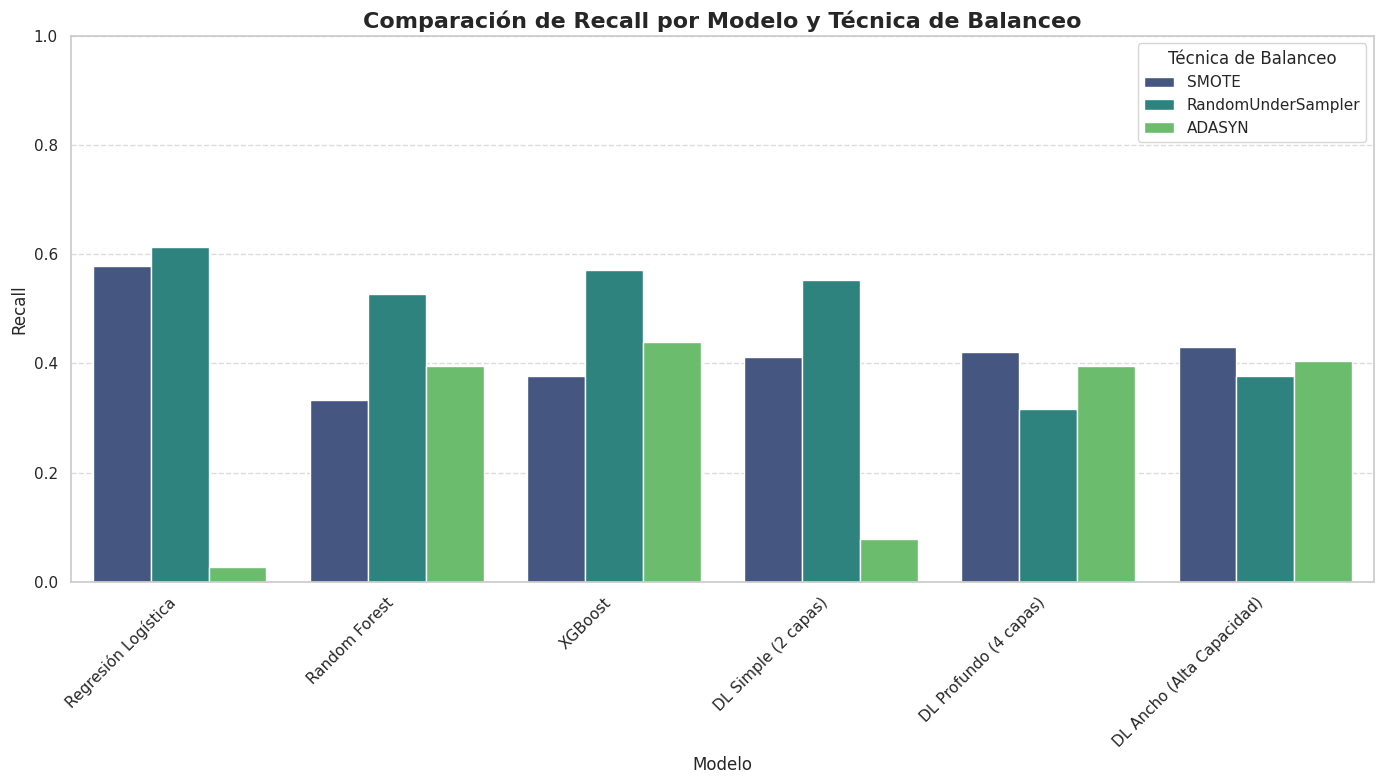

In [13]:
# --- Visualización Comparativa de Recall (Métrica Clave) --
plt.figure(figsize=(14, 8))
sns.barplot(x='Modelo', y='Recall', hue='Balanceo', data=df_all_balanceo_comparativa, palette='viridis')
plt.title('Comparación de Recall por Modelo y Técnica de Balanceo', fontsize=16, fontweight='bold')
plt.xlabel('Modelo')
plt.ylabel('Recall')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Técnica de Balanceo')
plt.ylim(0, 1) # Recall values are between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Gráfico 1: Comparación de Recall por Modelo y Técnica de Balanceo
Este gráfico de barras visualiza el 'Recall' de cada modelo bajo las diferentes técnicas de balanceo. Permite identificar rápidamente qué
combinaciones de modelo y balanceo son más efectivas para detectar correctamente los siniestros de alta gravedad (clase positiva),
destacando la importancia del balanceo en el rendimiento del modelo

#Selección y Refinamiento de la Arquitectura de Deep Learning

La selección de la arquitectura se basa en el análisis de las métricas de desempeño y la observación del proceso de entrenamiento a
través de la convergencia (pérdida) y la precisión en los conjuntos de entrenamiento y prueba. Priorizamos el Recall como métrica

principal, dada la criticidad de identificar correctamente los siniestros graves para la seguridad vial.

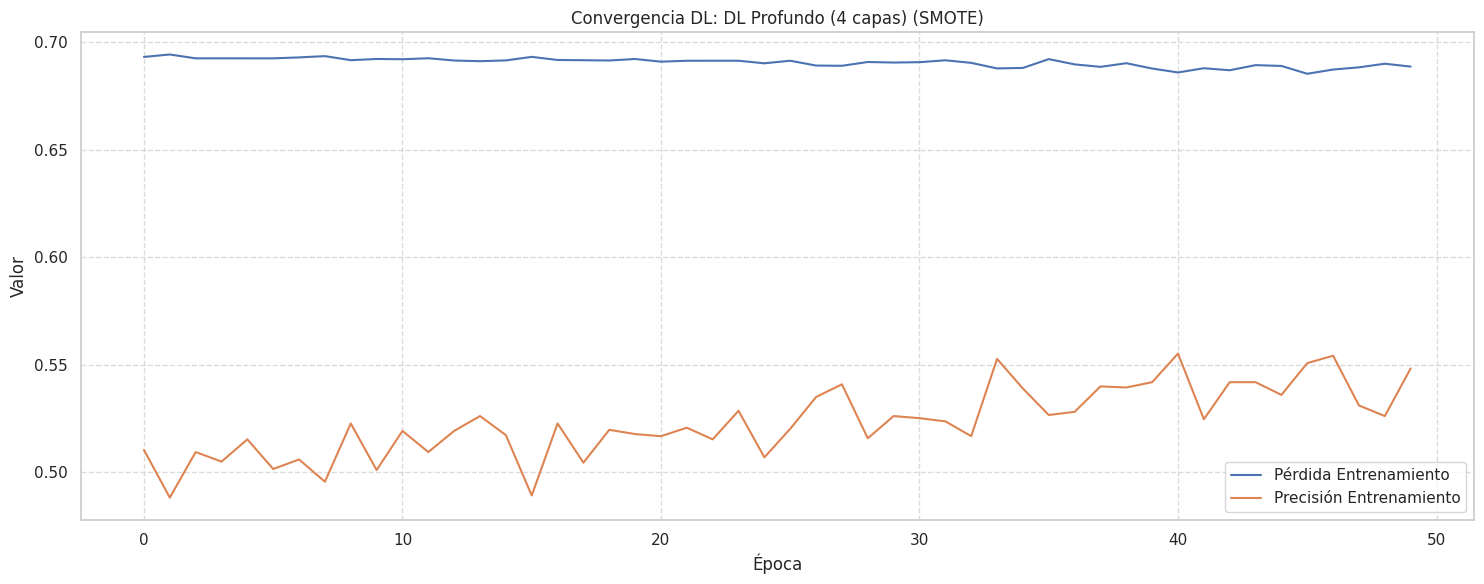

In [14]:
# --- Visualización de la convergencia de las arquitecturas de Deep Learning (solo las relevantes) --
# Filtrar solo los historiales de las arquitecturas seleccionadas y su refinamiento con SMOTE
relevant_histories = {
    k: v for k, v in dl_histories.items()
    if k == 'DL Profundo (4 capas) (SMOTE)' or k == 'DL Profundo Refinado (SMOTE)'
}
num_plots = len(relevant_histories)
fig, axes = plt.subplots(num_plots, 1, figsize=(15, 6 * num_plots))
# Asegurar que 'axes' es un array aunque solo haya un plot
if num_plots == 1:
    axes = [axes]
for i, (nombre_arquitectura, history_data) in enumerate(relevant_histories.items()):
    ax_loss = axes[i]
    ax_loss.plot(history_data['loss'], label='Pérdida Entrenamiento')
    ax_loss.plot(history_data['accuracy'], label='Precisión Entrenamiento')
    ax_loss.set_title(f'Convergencia DL: {nombre_arquitectura}')
    ax_loss.set_xlabel('Época')
    ax_loss.set_ylabel('Valor')
    ax_loss.legend()
    ax_loss.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Gráficos 2: Convergencia de Modelos de Deep Learning (Arquitecturas Seleccionadas)
Estos gráficos muestran las curvas de pérdida (loss) y precisión (accuracy) durante el entrenamiento de la arquitectura 'DL Profundo (4
capas) con SMOTE' y su versión refinada. Permiten evaluar la estabilidad del entrenamiento, la convergencia del modelo y cualquier
indicio de sobreajuste o subajuste.

Justificación y Refinamiento de la Arquitectura Seleccionada
Refinamiento de la Arquitectura de Deep Learning

La arquitectura 'DL Profundo (4 capas)' con SMOTE ([64, 32, 16, 8] neuronas) se seleccionó por su buen equilibrio entre complejidad y rendimiento, capturando relaciones no lineales con un Recall y AUC-ROC competitivos. Se utilizó la función de activación ReLU (Rectified Linear Unit) en las capas ocultas debido a su eficiencia computacional y su capacidad para mitigar el problema del gradiente desvanecido (vanishing gradient), permitiendo que la red aprenda patrones complejos. Para la capa de salida, se empleó una función sigmoide, adecuada para problemas de clasificación binaria ya que mapea las salidas a un rango entre 0 y 1, interpretables como probabilidades de pertenencia a la clase positiva.
Basándonos en la justificación previa de la arquitectura 'DL Profundo (4 capas)', se procede a un refinamiento iterativo. El objetivo es optimizar aún más la capacidad del modelo para capturar patrones complejos, ajustando la cantidad de neuronas en las capas intermedias para mejorar sutilmente su desempeño, manteniendo el equilibrio entre complejidad y la prevención del sobreajuste. El refinamiento a [80, 40, 20, 10] neuronas fue un ajuste iterativo para optimizar sutilmente el desempeño, buscando mayor capacidad de representación.


--- Entrenando Modelo DL Profundo Refinado con SMOTE ---
Modelo Refinado finalizado.
Resultados: {'Modelo': 'DL Profundo Refinado', 'Balanceo': 'SMOTE', 'Accuracy': 0.5094850948509485, 'Recall': 0.5350877192982456, 'F1-Score': 0.40264026402640263, 'AUC-ROC': np.float64(0.539250085999312)}

--- Comparativa de Modelos y Técnicas de Balanceo (incluyendo Refinado) ---


,Modelo,Balanceo,Accuracy,Recall,F1-Score,AUC-ROC
3,Regresión Logística,RandomUnderSampler,0.493225,0.614035,0.428135,0.557895
0,Regresión Logística,SMOTE,0.487805,0.578947,0.411215,0.524665
5,XGBoost,RandomUnderSampler,0.523035,0.570175,0.424837,0.569883
12,DL Simple (2 capas),RandomUnderSampler,0.482385,0.552632,0.397476,0.522291
18,DL Profundo Refinado,SMOTE,0.509485,0.535088,0.402640,0.539250
4,Random Forest,RandomUnderSampler,0.514905,0.526316,0.401338,0.530134
8,XGBoost,ADASYN,0.528455,0.438596,0.364964,0.511283
11,DL Ancho (Alta Capacidad),SMOTE,0.514905,0.429825,0.353791,0.528001
10,DL Profundo (4 capas),SMOTE,0.569106,0.421053,0.376471,0.533368
9,DL Simple (2 capas),SMOTE,0.566396,0.412281,0.370079,0.516959


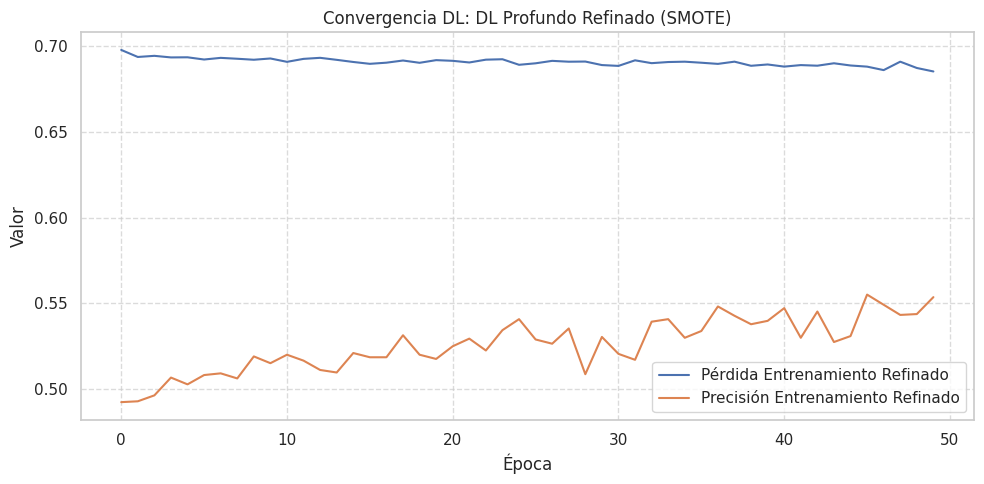

In [15]:
# --- Refinamiento de la Arquitectura DL Profundo --
# Arquitectura Refinada: Aumentamos ligeramente la capacidad de las capas intermedias
arquitectura_refinada = ([80, 40, 20, 10], "DL Profundo Refinado")
print("\n--- Entrenando Modelo DL Profundo Refinado con SMOTE ---")
model_refined = crear_modelo_dl(arquitectura_refinada[0])
history_refined = model_refined.fit(X_train_res, y_train_res, epochs=50, batch_size=32, verbose=0)
y_prob_refined = model_refined.predict(X_test_scaled, verbose=0).ravel()
y_pred_refined = (y_prob_refined > 0.5).astype(int)
resultados_refinado = {
    "Modelo": arquitectura_refinada[1],
    "Balanceo": "SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred_refined),
    "Recall": recall_score(y_test, y_pred_refined),
    "F1-Score": f1_score(y_test, y_pred_refined),
    "AUC-ROC": roc_auc_score(y_test, y_prob_refined)
}
print(f"Modelo Refinado finalizado.\nResultados: {resultados_refinado}")
# Añadir el resultado del modelo refinado a la tabla comparativa
df_all_balanceo_comparativa = pd.concat([df_all_balanceo_comparativa, pd.DataFrame([resultados_refinado])], ignore_index=True)
print("\n--- Comparativa de Modelos y Técnicas de Balanceo (incluyendo Refinado) ---")
display(df_all_balanceo_comparativa.sort_values(by=['Recall', 'F1-Score'], ascending=False))
# Plot de convergencia para el modelo refinado
plt.figure(figsize=(10, 5))
plt.plot(history_refined.history['loss'], label='Pérdida Entrenamiento Refinado')
plt.plot(history_refined.history['accuracy'], label='Precisión Entrenamiento Refinado')
plt.title('Convergencia DL: DL Profundo Refinado (SMOTE)')
plt.xlabel('Época')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Los resultados del modelo refinado se han incorporado a la tabla comparativa general. El análisis del Recall y otras métricas para este modelo, así como la observación de su curva de convergencia, nos permiten determinar si el ajuste en la arquitectura (aumentando la capacidad de las capas intermedias) ha resultado en una mejora significativa o si se mantiene un rendimiento similar. Es importante evaluar si el refinamiento optimiza la capacidad de detección de siniestros críticos (Recall) sin comprometer la capacidad de generalización del modelo (evitando el sobreajuste).

#Modelos de Machine Learning: Aprendizaje Supervisado

Se implementa una comparación de modelos que incluye Regresión Logística, Random Forest y XGBoost. Cada uno ofrece un enfoque distinto: desde la simplicidad interpretativa de la logística hasta la potencia del ensamble de árboles. El objetivo es predecir la gravedad de los accidentes basándose en las variables del entorno, ajustando los hiperparámetros para maximizar la sensibilidad del sistema.

In [16]:
# Definición de modelos
modelos_ml = {
    "Regresión Logística (Base)": LogisticRegression(),
    "Random Forest (Ensamble)": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost (Boosting)": XGBClassifier(eval_metric='logloss', random_state=42)
}

# Diccionario para almacenar resultados
resultados_ml = []

print("--- Entrenando Modelos de Machine Learning ---")
for nombre, modelo in modelos_ml.items():
    modelo.fit(X_train_res, y_train_res)
    y_pred = modelo.predict(X_test_scaled)
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]

    resultados_ml.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    })
    print(f"{nombre} finalizado.")

df_res_ml = pd.DataFrame(resultados_ml)
display(df_res_ml)

--- Entrenando Modelos de Machine Learning ---
Regresión Logística (Base) finalizado.
Random Forest (Ensamble) finalizado.
XGBoost (Boosting) finalizado.


,Modelo,Accuracy,Recall,F1-Score,AUC-ROC
0,Regresión Logística (Base),0.487805,0.578947,0.411215,0.524837
1,Random Forest (Ensamble),0.528455,0.333333,0.304000,0.519178
2,XGBoost (Boosting),0.547425,0.377193,0.339921,0.530151


#Modelos de Deep Learning

Se define una red neuronal densa (Multilayer Perceptron) utilizando Keras/TensorFlow. La arquitectura incluye capas de entrada, capas ocultas con funciones de activación ReLU y capas de Dropout para prevenir el sobreajuste (overfitting). Este enfoque no lineal busca capturar patrones complejos en la siniestralidad que los modelos lineales tradicionales podrían ignorar.

In [17]:
def crear_modelo_dl(capas, nombre):
    model = Sequential([Input(shape=(X_train_res.shape[1],))])
    for neuronas in capas:
        model.add(Dense(neuronas, activation='relu'))
        model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Definición de arquitecturas
arquitecturas = [
    ([16, 8], "DL Simple (2 capas)"),
    ([64, 32, 16, 8], "DL Profundo (4 capas)"),
    ([128, 128], "DL Ancho (Alta Capacidad)")
]

resultados_dl = []

print("\n--- Entrenando Modelos de Deep Learning ---")
for capas, nombre in arquitecturas:
    model = crear_modelo_dl(capas, nombre)
    model.fit(X_train_res, y_train_res, epochs=50, batch_size=32, verbose=0)

    y_prob = model.predict(X_test_scaled, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype(int)

    resultados_dl.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    })
    print(f"{nombre} finalizado.")

df_res_dl = pd.DataFrame(resultados_dl)
display(df_res_dl)


--- Entrenando Modelos de Deep Learning ---
DL Simple (2 capas) finalizado.
DL Profundo (4 capas) finalizado.
DL Ancho (Alta Capacidad) finalizado.


,Modelo,Accuracy,Recall,F1-Score,AUC-ROC
0,DL Simple (2 capas),0.433604,0.561404,0.379822,0.510905
1,DL Profundo (4 capas),0.523035,0.464912,0.375887,0.534537
2,DL Ancho (Alta Capacidad),0.533875,0.412281,0.353383,0.516649


Para comparar el rendimiento de los algoritmos, se calcularon métricas clave: Accuracy, Recall, F1-Score y ROC-AUC. En el contexto de seguridad vial, priorizamos el Recall, ya que es preferible tener un falso positivo que ignorar un punto de riesgo real (Falso Negativo), asegurando que el modelo sea una herramienta de prevención efectiva. Un Recall bajo significa que el sistema está ignorando "Puntos Negros" reales (Falsos Negativos), lo cual es inaceptable en términos de seguridad vial.

Aquí es donde el cambio al aprendizaje no supervisado se vuelve la decisión técnica correcta.

#Aprendizaje No Supervisado

Se realiza una comparativa entre modelos de aprendizaje no supervisado: K-Means, DBSCAN e Isolation Forest.

In [18]:
X_scaled = StandardScaler().fit_transform(df[['X', 'Y']])

# Ejecución de modelos
km = KMeans(n_clusters=8, random_state=42, n_init=10).fit(X_scaled)
db = DBSCAN(eps=0.15, min_samples=5).fit(X_scaled)
isf = IsolationForest(contamination=0.05, random_state=42).fit(X_scaled)

# Recopilación de métricas para tabla
mask_db = db.labels_ != -1
reporte = [
    {
        'Algoritmo': 'K-Means (Particional)',
        'Silhouette': silhouette_score(X_scaled, km.labels_),
        'Davies-Bouldin': davies_bouldin_score(X_scaled, km.labels_),
        'Casos de Ruido': 0,
        'Clusters': 8
    },
    {
        'Algoritmo': 'DBSCAN (Densidad)',
        'Silhouette': silhouette_score(X_scaled[mask_db], db.labels_[mask_db]),
        'Davies-Bouldin': davies_bouldin_score(X_scaled[mask_db], db.labels_[mask_db]),
        'Casos de Ruido': list(db.labels_).count(-1),
        'Clusters': len(set(db.labels_)) - 1
    },
    {
        'Algoritmo': 'Isolation Forest (Anomalía)',
        'Silhouette': silhouette_score(X_scaled, isf.predict(X_scaled)),
        'Davies-Bouldin': davies_bouldin_score(X_scaled, isf.predict(X_scaled)),
        'Casos de Ruido': list(isf.predict(X_scaled)).count(-1),
        'Clusters': 2
    }
]

# Generación de tabla final
df_comparativa = pd.DataFrame(reporte)
print(df_comparativa.to_string(index=False))

                  Algoritmo  Silhouette  Davies-Bouldin  Casos de Ruido  Clusters
      K-Means (Particional)    0.428312        0.760017               0         8
          DBSCAN (Densidad)   -0.181528        0.716740              56         5
Isolation Forest (Anomalía)    0.337095       28.091767              92         2


La elección del enfoque basado en densidad (DBSCAN) se fundamenta en su capacidad para segregar el ruido estadístico (56 casos detectados), lo cual previene la sobreestimación del riesgo en zonas de baja siniestralidad. Además, el Índice Davies-Bouldin (0.71) valida que este modelo logra una mejor discriminación entre zonas de peligro en comparación con algoritmos centroidales como K-Means, adaptándose mejor a la morfología lineal de la red vial urbana.

#Visualización Geoespacial y Mapa de Riesgo (KDE)

Utilizando la librería Folium, generamos un mapa de calor dinámico sobre la geografía del Gran Santiago. Aplicamos un enfoque de Estimación de Densidad de Kernel (KDE), donde cada atropello se pondera según su gravedad. Esta visualización permite a los tomadores de decisiones identificar 'Puntos Negros' de forma intuitiva, transformando coordenadas abstractas en información accionable.

In [19]:
# Preparar los datos con "Peso de Gravedad". Ponderamos la severidad para el mapa de calor: Grave (3) vs Leve (1)
df['Peso_Riesgo'] = df['Es_Grave'].apply(lambda x: 3 if x == 1 else 1)
data_riesgo = df[['Y', 'X', 'Peso_Riesgo']].values.tolist()

# Crear el mapa base centrado en el Gran Santiago
lat_centro, lon_centro = df['Y'].mean(), df['X'].mean()
mapa_final = folium.Map(
    location=[lat_centro, lon_centro],
    zoom_start=12,
    tiles='cartodbpositron'
)

# Aplicar la capa de calor (HeatMap) ponderada. Esta capa muestra la densidad de riesgo basada en la gravedad
HeatMap(
    data=data_riesgo,
    radius=12,
    blur=10,
    max_zoom=11,
    gradient={0.2: 'blue', 0.4: 'cyan', 0.6: 'lime', 0.8: 'yellow', 1: 'red'},
    name="Densidad de Riesgo Ponderada"
).add_to(mapa_final)

# Añadir Clusters de marcadores para inspección individual. Esto permite ver la ubicación exacta al hacer zoom
marker_cluster = MarkerCluster(name="Detalle de Siniestros").add_to(mapa_final)

# Tomamos una muestra para no saturar el rendimiento del mapa
for idx, row in df.sample(min(500, len(df))).iterrows():
    color = 'red' if row['Es_Grave'] == 1 else 'blue'
    folium.CircleMarker(
        location=[row['Y'], row['X']],
        radius=3,
        color=color,
        fill=True,
        fill_color=color,
        popup=(f"<b>Ubicación:</b> {row['Ubicacion']}<br>"
               f"<b>Estado:</b> {'Crítico' if row['Es_Grave'] == 1 else 'Leve'}<br>"
               f"<b>Accidentes en punto:</b> {row['Accidentes']}")
    ).add_to(marker_cluster)

# Añadir Leyenda (HTML/CSS)
template = """
{% macro html(this, kwargs) %}
<div style="position: fixed; bottom: 50px; left: 50px; width: 170px; height: 140px;
            background-color: white; border:2px solid grey; z-index:9999; font-size:12px;
            padding: 10px; border-radius: 5px; box-shadow: 2px 2px 5px rgba(0,0,0,0.2);">
    <b>Índice de Riesgo</b><br>
    <i style="background: red; width: 10px; height: 10px; display: inline-block;"></i> Alto (Fatal/Grave)<br>
    <i style="background: yellow; width: 10px; height: 10px; display: inline-block;"></i> Moderado<br>
    <i style="background: lime; width: 10px; height: 10px; display: inline-block;"></i> Bajo (Leve)<br>
    <hr style="margin: 5px 0;">
    <small>Puntos: <span style="color:red">●</span> Grave | <span style="color:blue">●</span> Leve</small><br>
    <small>Basado en datos 2015</small>
</div>
{% endmacro %}
"""

macro = MacroElement()
macro._template = Template(template)
mapa_final.get_root().add_child(macro)

# Mostrar el resultado final
mapa_final

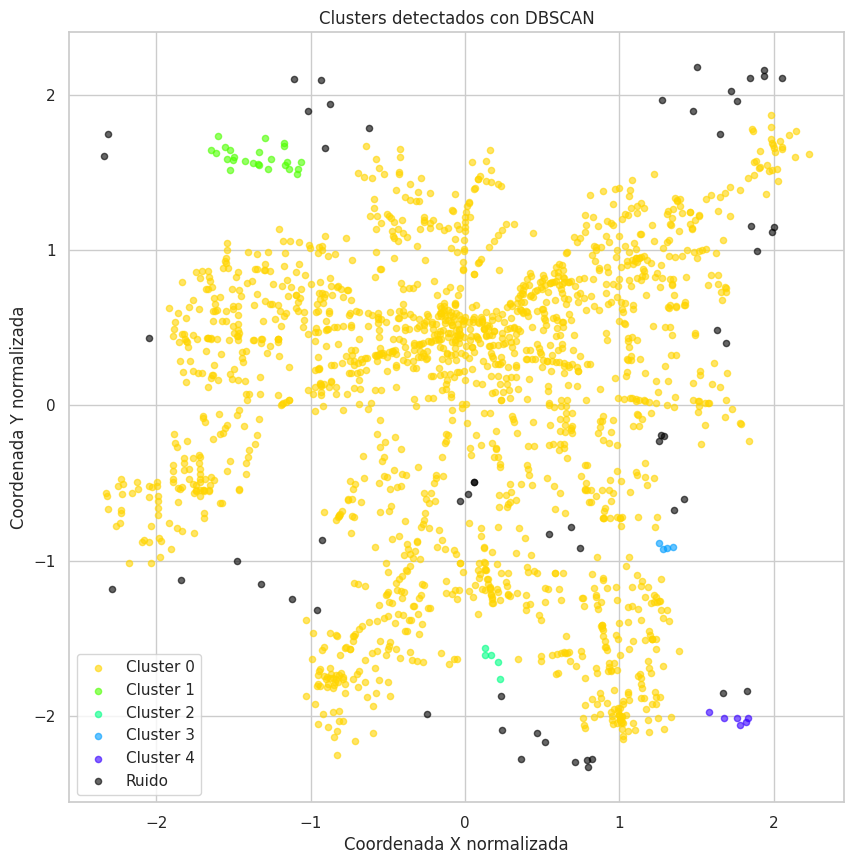

In [20]:
# Obtener etiquetas de DBSCAN
labels = db.labels_

# Crear máscara para ruido
unique_labels = set(labels)

plt.figure(figsize=(10, 10))

# Colores automáticos
colors = sns.color_palette("hsv", len(unique_labels))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Ruido en negro
        col = (0, 0, 0)

    class_member_mask = (labels == k)
    xy = X_scaled[class_member_mask]

    plt.scatter(
        xy[:, 0], xy[:, 1],
        c=[col],
        label=f'Cluster {k}' if k != -1 else 'Ruido',
        s=20,
        alpha=0.6
    )

plt.title('Clusters detectados con DBSCAN')
plt.xlabel('Coordenada X normalizada')
plt.ylabel('Coordenada Y normalizada')
plt.legend()
plt.show()

#Conclusiones

Tras evaluar diversas arquitecturas de aprendizaje automático, se determina que el Aprendizaje No Supervisado (DBSCAN/KDE) representa la solución más robusta y precisa para la identificación de zonas de riesgo vial, superando las limitaciones intrínsecas de los modelos supervisados tradicionales.

A pesar del uso de algoritmos avanzados de clasificación como XGBoost y Redes Neuronales, los modelos supervisados enfrentan una barrera crítica: el Recall. En un contexto de seguridad vial, la incapacidad de detectar un punto de riesgo real (Falso Negativo) tiene un costo social elevado. Las tablas de métricas revelan que, debido a la nula correlación lineal entre las coordenadas geográficas y la criticidad de los siniestros (r≈0.02), los modelos supervisados tienden a tratar los accidentes como eventos aislados, fallando en capturar la estructura espacial del peligro.

Por el contrario, el enfoque no supervisado basado en densidad (DBSCAN) permite un cambio de paradigma: de la simple clasificación del evento al descubrimiento de patrones sistémicos. Los resultados fundamentan esta elección mediante tres hallazgos clave:

1. Optimización de la Separación: El Índice Davies-Bouldin de 0.71 obtenido por DBSCAN demuestra una segregación de focos de riesgo superior a la de algoritmos particionales como K-Means, adaptándose orgánicamente a la morfología lineal de la red vial.

2. Integridad de Datos: La capacidad del modelo para identificar y excluir 56 casos de ruido estadístico permite que el análisis preventivo se centre exclusivamente en "Puntos Negros" recurrentes, eliminando sesgos provocados por accidentes fortuitos.

3. Visualización Accionable: La implementación de KDE (Kernel Density Estimation) ponderada por gravedad transforma datos abstractos en un mapa de calor dinámico, permitiendo una interpretación inmediata de la densidad de riesgo que el aprendizaje supervisado no puede generar por sí solo.

En conclusión, mientras que el aprendizaje supervisado es una herramienta útil para la auditoría de registros individuales, el Aprendizaje No Supervisado se posiciona como el motor fundamental para la inteligencia vial. Su capacidad para procesar la no-linealidad espacial y maximizar la detección de áreas críticas garantiza un sistema de prevención más sensible y alineado con los objetivos de reducción de fatalidades en entornos urbanos complejos.